In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("C:\\Users\\apadh\\OneDrive\\Desktop\\project\\credit_card\\credit_card_fraud_10k.csv")

In [4]:
df.head(3)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0


In [5]:
df.tail(3)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [7]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [8]:
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [9]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [10]:
df[df.duplicated]

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud


# Corr Heatmap

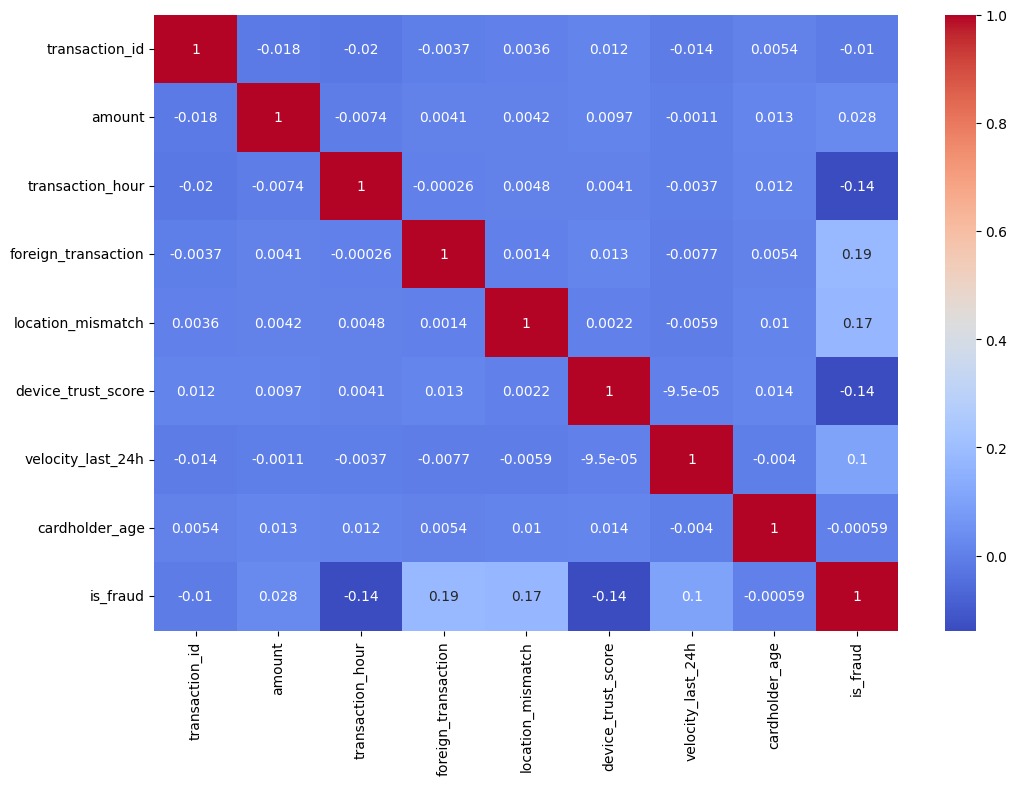

In [11]:
df_copy= pd.get_dummies(df, columns=["merchant_category"])
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# Drop Unwanted Columns

In [12]:
df.drop(columns=["transaction_id","cardholder_age","merchant_category"],inplace=True)

In [13]:
df.columns

Index(['amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'is_fraud'],
      dtype='object')

# X and Y Splitting

In [14]:
X = df.iloc[:,:-1]

In [15]:
X

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h
0,84.47,22,0,0,66,3
1,541.82,3,1,0,87,1
2,237.01,17,0,0,49,1
3,164.33,4,0,1,72,3
4,30.53,15,0,0,79,0
...,...,...,...,...,...,...
9995,350.91,22,0,0,99,4
9996,410.04,5,0,0,70,3
9997,527.75,21,0,0,44,2
9998,91.20,2,0,0,38,0


In [16]:
Y=df.iloc[:,-1]

In [17]:
Y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: is_fraud, Length: 10000, dtype: int64

# Split X and Y into X_train,X_test,Y_train,Y_test


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

# Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print(X_train)
print(X_test)

[[ 0.51171138  0.93507691 -0.33078115 -0.30380798  0.74876492 -0.00843872]
 [-0.72349331 -0.80049757 -0.33078115 -0.30380798 -1.20865335 -0.7044157 ]
 [-0.50916374  0.50118329 -0.33078115 -0.30380798 -1.11544295 -0.7044157 ]
 ...
 [-0.84688828  0.50118329  3.02314687 -0.30380798 -0.4629702   0.68753825]
 [ 0.53304735 -0.94512878 -0.33078115 -0.30380798 -0.74260138 -0.7044157 ]
 [-0.60397762 -1.66828481 -0.33078115  3.29155275  1.54105326 -0.00843872]]
[[-5.78305991e-01 -1.08975999e+00 -3.30781151e-01 -3.03807982e-01
   1.21481688e+00 -7.04415696e-01]
 [ 5.32933255e-01  6.72896690e-02 -3.30781151e-01  3.29155275e+00
  -7.89206576e-01 -7.04415696e-01]
 [ 3.07083313e-03 -9.45128780e-01 -3.30781151e-01 -3.03807982e-01
  -9.01286249e-02 -8.43872082e-03]
 ...
 [-6.41058862e-01 -8.00497573e-01 -3.30781151e-01 -3.03807982e-01
   1.68086885e+00 -1.40039267e+00]
 [-8.01649163e-01  3.56552083e-01 -3.30781151e-01 -3.03807982e-01
   7.95370114e-01 -7.04415696e-01]
 [ 4.27192379e-02  7.90445704e-01 

# Applying SMOTE

In [20]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
X_train,Y_train=sm.fit_resample(X_train,Y_train)

In [21]:
Y_train.value_counts()

is_fraud
0    7880
1    7880
Name: count, dtype: int64

# Which Model is more accurate

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score

models=[DecisionTreeClassifier,KNeighborsClassifier,GaussianNB,RandomForestClassifier]

for model in models:
    md=model()
    md.fit(X_train,Y_train)
    y_pred=md.predict(X_test)
    print("=============",model,"============")
    print("accuracy_score",accuracy_score(Y_test,y_pred)*100)
    print("F1score",f1_score(Y_test,y_pred)*100)

============= <class 'sklearn.tree._classes.DecisionTreeClassifier'> ============
accuracy_score 99.75
F1score 92.06349206349206
============= <class 'sklearn.neighbors._classification.KNeighborsClassifier'> ============
accuracy_score 98.85000000000001
F1score 72.28915662650603
============= <class 'sklearn.naive_bayes.GaussianNB'> ============
accuracy_score 90.75
F1score 23.868312757201647
============= <class 'sklearn.ensemble._forest.RandomForestClassifier'> ============
accuracy_score 99.85000000000001
F1score 95.08196721311475


In [23]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=11)
rf.fit(X_train,Y_train)
y_pred=rf.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print("accuracy_score",accuracy_score(Y_test,y_pred)*100)
print("F1score",f1_score(Y_test,y_pred)*100)
print("precision_score",precision_score(Y_test,y_pred)*100)
print("recall",recall_score(Y_test,y_pred)*100)

accuracy_score 99.9
F1score 96.7741935483871
precision_score 96.7741935483871
recall 96.7741935483871


In [25]:
import joblib

In [26]:
joblib.dump(rf,"rf.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [27]:
X.head(122)

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h
0,84.47,22,0,0,66,3
1,541.82,3,1,0,87,1
2,237.01,17,0,0,49,1
3,164.33,4,0,1,72,3
4,30.53,15,0,0,79,0
...,...,...,...,...,...,...
117,37.17,6,1,0,83,4
118,401.55,2,0,0,46,1
119,139.52,14,0,0,61,0
120,296.52,0,0,0,99,3


In [28]:
Y.head(122)

0      0
1      0
2      0
3      0
4      0
      ..
117    0
118    0
119    0
120    0
121    1
Name: is_fraud, Length: 122, dtype: int64